ASPI_Return p-value: 5.209787428595401e-19
Banks_Return p-value: 0.0
Capital_Goods_Return p-value: 6.057692358923351e-26
Consumer_Durables_and_Apparel_Return p-value: 3.41499172975085e-23
Consumer_Services_Return p-value: 1.0198101846145956e-17
Diversified_Financials_Return p-value: 5.367848854579398e-13
Energy_Return p-value: 3.179189547596049e-23
Food,_Beverage_and_Tobacco_Return p-value: 2.7850893278502213e-09
Materials_Return p-value: 2.3770141367212964e-12
Real_Estate_Management_and_Development_Return p-value: 0.0
Retailing_Return p-value: 1.989097956326741e-17
Telecommunication_Services_Return p-value: 5.752076741153996e-25
Healthcare_Equipment_and_Services_Return p-value: 9.777773230174667e-27
Insurance_Return p-value: 0.0
CCPI p-value: 0.7773096758171668
SLFR p-value: 0.6603165578925551
USD_LKR p-value: 0.5026532659593056


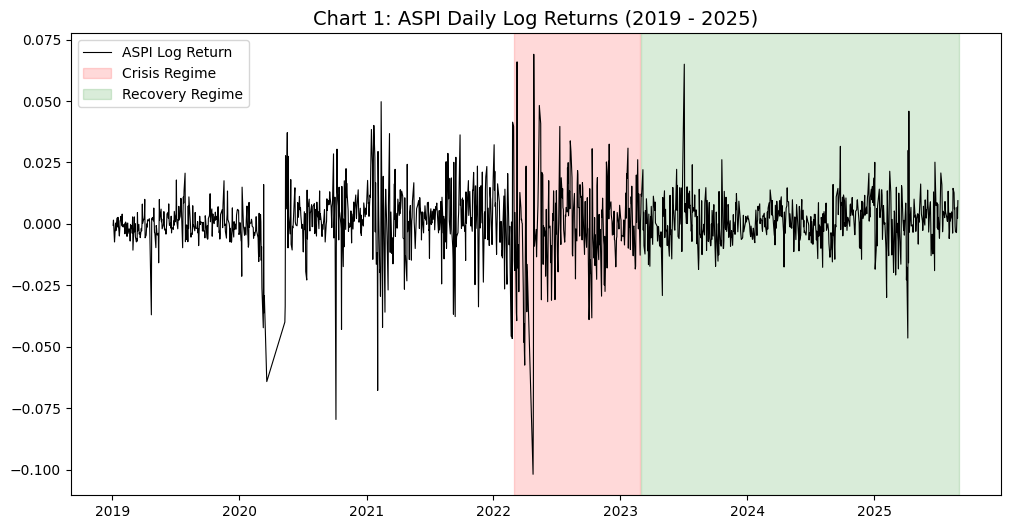

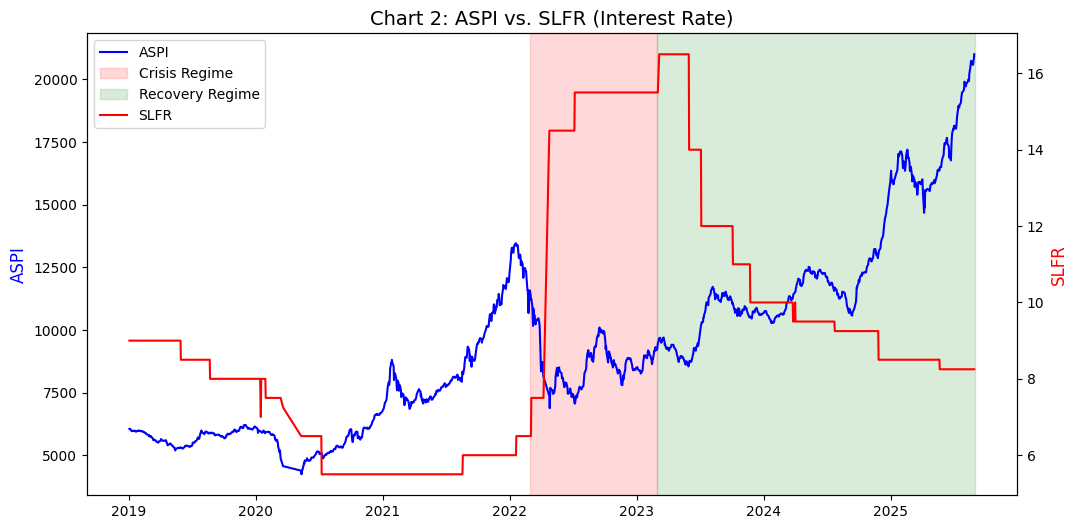

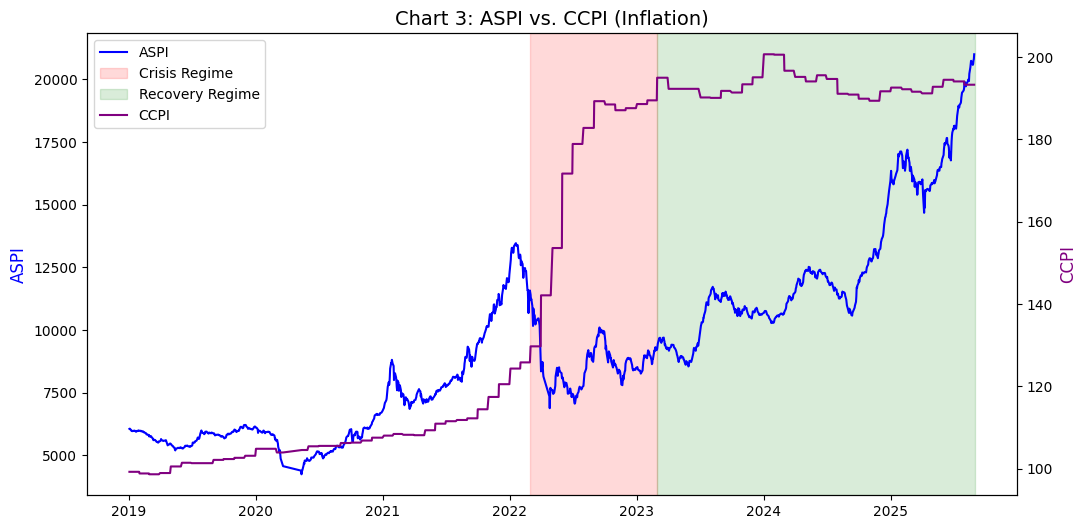

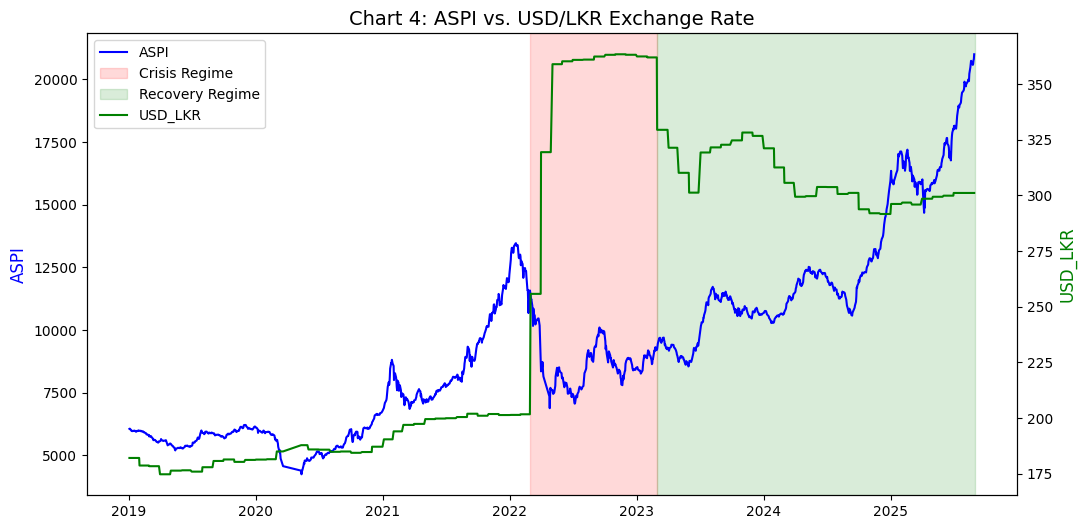

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

# 1. Load the cleaned master dataset
df = pd.read_csv('../../master_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# Rename macro columns for easier plotting
df.rename(columns={
    'Reverse_Repo_Standing_Lending_Facility_Rate': 'SLFR',
    'Monthly_Average_Exchange_Rates': 'USD_LKR',
    'CCPI_2021_Base': 'CCPI'
}, inplace=True)

# 2. Calculate Log Returns for ASPI and all 9 Sectors
sectors = [
    'Banks', 'Capital_Goods', 'Consumer_Durables_and_Apparel', 
    'Consumer_Services', 'Diversified_Financials', 'Energy', 
    'Food,_Beverage_and_Tobacco', 'Materials', 'Real_Estate_Management_and_Development',
    'Retailing', 'Telecommunication_Services', 'Healthcare_Equipment_and_Services', 'Insurance',
]
price_cols = ['ASPI'] + sectors

for col in price_cols:
    df[f'{col}_Return'] = np.log(df[col] / df[col].shift(1))

# Drop the first row (NaN due to shifting)
df.dropna(subset=['ASPI_Return'], inplace=True)

# 3. ADF Stationarity Test 
def run_adf(series):
    result = adfuller(series.dropna())
    return result[1]

test_vars = [f'{col}_Return' for col in price_cols] + ['CCPI', 'SLFR', 'USD_LKR']
for var in test_vars:
    print(f"{var} p-value: {run_adf(df[var])}")

# 4. Regime Shading Setup
crisis_start, crisis_end = '2022-03-01', '2023-02-28'
recovery_start, recovery_end = '2023-03-01', '2025-08-31'

def apply_shading(ax):
    ax.axvspan(pd.to_datetime(crisis_start), pd.to_datetime(crisis_end), color='red', alpha=0.15, label='Crisis Regime')
    ax.axvspan(pd.to_datetime(recovery_start), pd.to_datetime(recovery_end), color='green', alpha=0.15, label='Recovery Regime')

# Chart 1: ASPI Log Returns
plt.figure(figsize=(12, 6))
ax = plt.gca()
ax.plot(df.index, df['ASPI_Return'], color='black', linewidth=0.8, label='ASPI Log Return')
apply_shading(ax)
plt.title('Chart 1: ASPI Daily Log Returns (2019 - 2025)', fontsize=14)
ax.legend(loc='upper left')
plt.show()

# Helper for Dual Axis Charts (2, 3, & 4)
def create_dual_chart(df, y1, y2, title, y2_color='orange'):
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.plot(df.index, df[y1], color='blue', linewidth=1.5, label=y1)
    ax1.set_ylabel(y1, color='blue', fontsize=12)
    
    ax2 = ax1.twinx()
    ax2.plot(df.index, df[y2], color=y2_color, linewidth=1.5, label=y2)
    ax2.set_ylabel(y2, color=y2_color, fontsize=12)
    
    apply_shading(ax1)
    plt.title(title, fontsize=14)
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
    plt.show()

create_dual_chart(df, 'ASPI', 'SLFR', 'Chart 2: ASPI vs. SLFR (Interest Rate)', 'red')
create_dual_chart(df, 'ASPI', 'CCPI', 'Chart 3: ASPI vs. CCPI (Inflation)', 'purple')
create_dual_chart(df, 'ASPI', 'USD_LKR', 'Chart 4: ASPI vs. USD/LKR Exchange Rate', 'green')

# # Chart 5: Sector Correlation Heatmap
# sector_cols = [f'{col}_Return' for col in sectors]
# corr = df[sector_cols].corr()

# # Clean up column names for a better-looking heatmap
# corr.columns = [c.replace('_Return', '').replace('_', ' ') for c in corr.columns]
# corr.index = [i.replace('_Return', '').replace('_', ' ') for i in corr.index]

# plt.figure(figsize=(12, 10))
# sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt=".2f", linewidths=.5)
# plt.title('Chart 5: Sector Correlation Heatmap (2019-2025)', fontsize=14)
# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()
# plt.show()

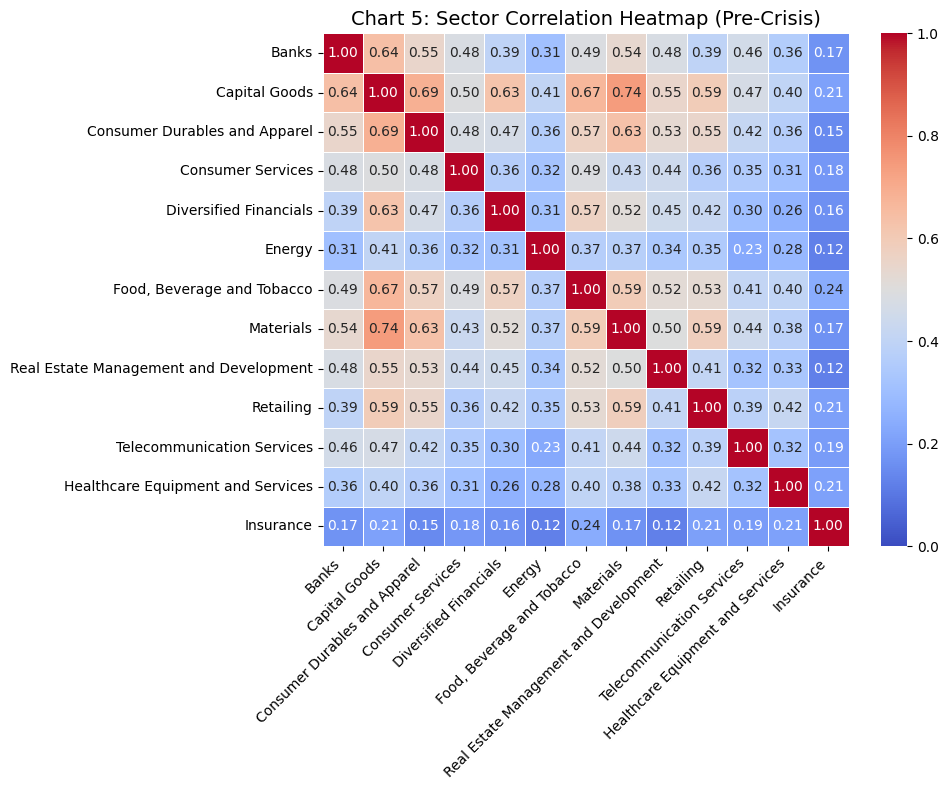

Saved: Chart_5_Pre-Crisis_Heatmap.png


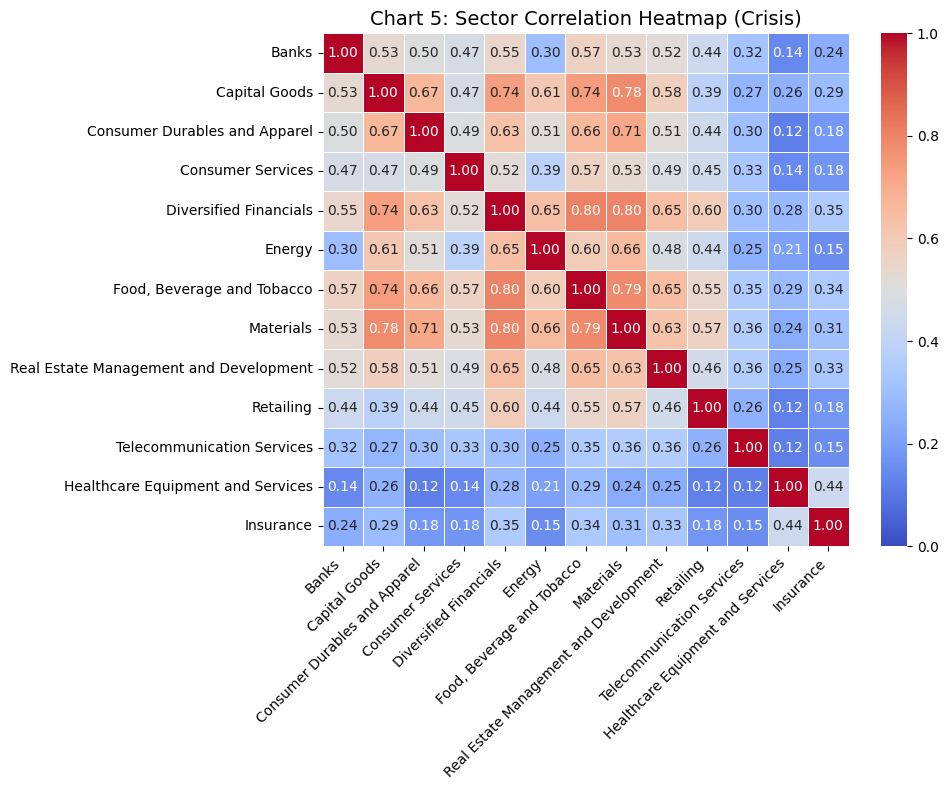

Saved: Chart_5_Crisis_Heatmap.png


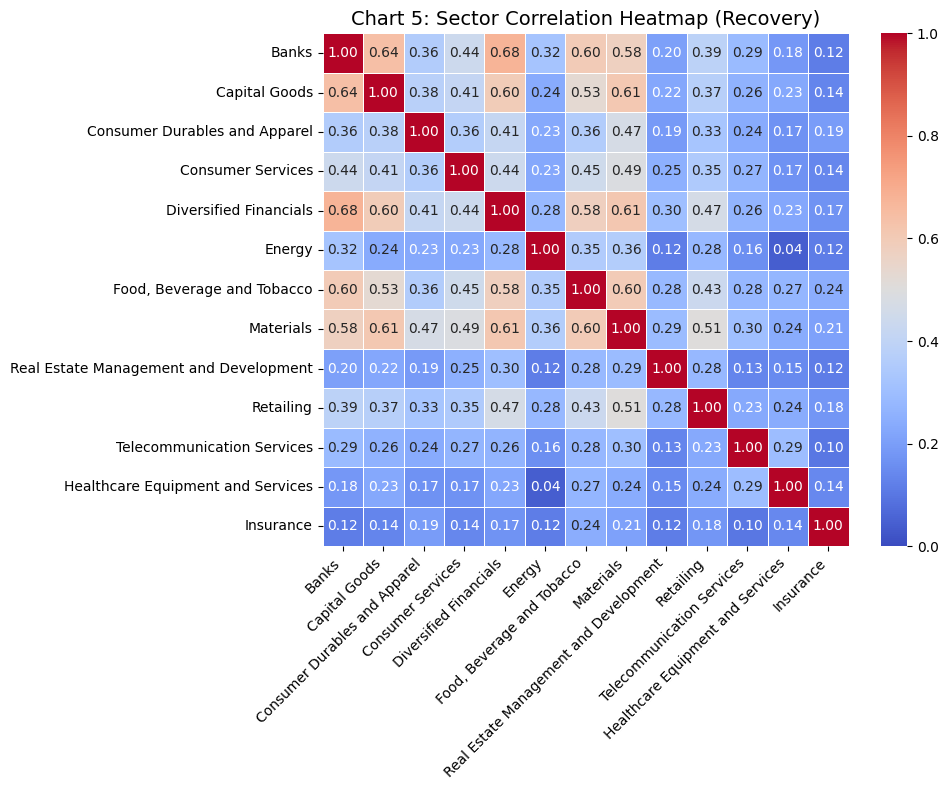

Saved: Chart_5_Recovery_Heatmap.png


In [3]:
# 1. Load the cleaned master dataset
df = pd.read_csv('../../master_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# 2. Define the sectors and calculate returns
sectors = [
    'Banks', 'Capital_Goods', 'Consumer_Durables_and_Apparel', 
    'Consumer_Services', 'Diversified_Financials', 'Energy', 
    'Food,_Beverage_and_Tobacco', 'Materials', 'Real_Estate_Management_and_Development',
    'Retailing', 'Telecommunication_Services', 'Healthcare_Equipment_and_Services', 'Insurance',
]
for col in sectors:
    df[f'{col}_Return'] = np.log(df[col] / df[col].shift(1))
df.dropna(inplace=True)

sector_cols = [f'{col}_Return' for col in sectors]
clean_names = [c.replace('_Return', '').replace('_', ' ') for c in sector_cols]

# 3. Define the three exact periods based on your project scope
periods = {
    'Pre-Crisis': ('2019-01-01', '2022-02-28'),
    'Crisis': ('2022-03-01', '2023-02-28'),
    'Recovery': ('2023-03-01', '2025-08-31')
}

# 4. Loop through each period, slice the data, and generate a heatmap
for title, (start, end) in periods.items():
    # Slice the dataframe to only include the current period
    mask = (df.index >= start) & (df.index <= end)
    period_df = df.loc[mask, sector_cols]
    
    # Calculate correlation matrix for this specific period
    corr = period_df.corr()
    corr.columns = clean_names
    corr.index = clean_names
    
    # Plot the heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt=".2f", linewidths=.5)
    plt.title(f'Chart 5: Sector Correlation Heatmap ({title})', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    # Save the image automatically
    filename = f'Chart_5_{title}_Heatmap.png'
    plt.savefig(filename, dpi=300)
    plt.show()
    print(f"Saved: {filename}")

In [ ]:
from scipy.stats import jarque_bera
import numpy as np

if 'ASPI_Return' not in df.columns and 'ASPI' in df.columns:
    df['ASPI_Return'] = np.log(df['ASPI'] / df['ASPI'].shift(1))

other_return_cols = sorted([c for c in df.columns if c.endswith('_Return') and c != 'ASPI_Return'])
return_cols = ['ASPI_Return'] + other_return_cols if 'ASPI_Return' in df.columns else other_return_cols

print('--- Jarque-Bera Test for Normality ---')
for col in return_cols:
    clean_data = df[col].dropna()

    if clean_data.empty:
        print(f'{col}: no valid data')
        print('-' * 30)
        continue

    jb_stat, p_value = jarque_bera(clean_data)

    print(f'{col}:')
    print(f'  JB Statistic: {jb_stat:.2f}')
    print(f'  P-value: {p_value}')
    print('-' * 30)

--- Jarque-Bera Test for Normality ---
ASPI_Return:
  JB Statistic: 4432.88
  P-value: 0.0
------------------------------
Banks_Return:
  JB Statistic: 12813.26
  P-value: 0.0
------------------------------
Capital_Goods_Return:
  JB Statistic: 15016.34
  P-value: 0.0
------------------------------
Consumer_Durables_and_Apparel_Return:
  JB Statistic: 8812.33
  P-value: 0.0
------------------------------
Consumer_Services_Return:
  JB Statistic: 2052.46
  P-value: 0.0
------------------------------
Diversified_Financials_Return:
  JB Statistic: 4074.11
  P-value: 0.0
------------------------------
Energy_Return:
  JB Statistic: 8565.05
  P-value: 0.0
------------------------------
Food,_Beverage_and_Tobacco_Return:
  JB Statistic: 4775.36
  P-value: 0.0
------------------------------
Healthcare_Equipment_and_Services_Return:
  JB Statistic: 5391.72
  P-value: 0.0
------------------------------
Insurance_Return:
  JB Statistic: 122879.24
  P-value: 0.0
------------------------------
Mat